# M87 Black Hole Image Reconstruction 🌌

## 1. Imports and Setup 🛠️

In [56]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from scipy.optimize import minimize

# Ensure graphics inline display
%matplotlib inline

print("All dependencies imported successfully!")

All dependencies imported successfully!


## 2. Data Loading & Initial Exploration 🗂️

In [57]:
UVFITS_PATH = Path(
    "data/EHTC_FirstM87Results_Apr2019/uvfits/"
    "SR1_M87_2017_095_hi_hops_netcal_StokesI.uvfits"
)

if not UVFITS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {UVFITS_PATH}. Please check your dataset path."
    )

with fits.open(UVFITS_PATH, memmap=False) as hdul:
    print("FITS Structure:")
    hdul.info()
    
    header = hdul[0].header
    data = hdul[0].data

print("\nKey Header Information:")
for key in ["OBJECT", "TELESCOP", "DATE-OBS", "CRVAL4"]:
    if key in header:
        print(f"  {key} = {header[key]}")

FITS Structure:
Filename: data\EHTC_FirstM87Results_Apr2019\uvfits\SR1_M87_2017_095_hi_hops_netcal_StokesI.uvfits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 GroupsHDU       82   (3, 4, 1, 1, 1, 1)   float32   6458 Groups  9 Parameters
  1  AIPS AN       1 BinTableHDU     60   8R x 13C   [8A, 3D, 1E, 1J, 1J, 1E, 1A, 1E, 3E, 1A, 1E, 3E, 1D]   
  2  AIPS FQ       1 BinTableHDU     21   1R x 5C   [1J, 1D, 1E, 1E, 1J]   

Key Header Information:
  OBJECT = M87
  TELESCOP = VLBA
  DATE-OBS = 2017-04-05
  CRVAL4 = 229070703125.0


Now we have the basic strucure of the data figured out we can turn it into a pandas DataFrame which will make it much easier to work with. The original UVFITS format contains the measurements in a multidimensional array, which can be difficult to work with directly. A DataFrame gives us a much simpler table containing the quantities we will use during the reconstruction:

* `u` — Fourier-plane u coordinate
* `v` — Fourier-plane v coordinate
* `real` — real component of the complex visibility
* `imag` — imaginary component of the complex visibility
* `weight` — measurement weight

This should give us one row per measurement, with 6,458 measurements in total.

In [58]:
parnames = list(data.parnames)
u_name = next((p for p in parnames if p.upper() in ["UU---SIN", "UU"]), None)
v_name = next((p for p in parnames if p.upper() in ["VV---SIN", "VV"]), None)

u_sec = np.asarray(data.par(u_name), dtype=np.float64)
v_sec = np.asarray(data.par(v_name), dtype=np.float64)

raw = np.asarray(data.data)
comp_axis = [i for i, n in enumerate(raw.shape[1:]) if n == 3][-1]
arr = np.moveaxis(raw, comp_axis + 1, -1)
arr = arr.reshape(arr.shape[0], -1, 3)

stokes_I = arr[:, 0, :]
real = np.asarray(stokes_I[:, 0], dtype=np.float64)
imag = np.asarray(stokes_I[:, 1], dtype=np.float64)
weight = np.asarray(stokes_I[:, 2], dtype=np.float64)

frequency = float(header.get("CRVAL4", 299792458.0 / 1.3e-3))
u_Glambda = (u_sec * frequency) / 1e9
v_Glambda = (v_sec * frequency) / 1e9

# Build Pandas DataFrame 
df = pd.DataFrame({
    "u_Glambda": u_Glambda,
    "v_Glambda": v_Glambda,
    "real": real,
    "imag": imag,
    "weight": weight,
    "amplitude": np.hypot(real, imag),
    "phase": np.arctan2(imag, real),
    "baseline_Glambda": np.hypot(u_Glambda, v_Glambda)
})

df.head()

,u_Glambda,v_Glambda,real,imag,weight,amplitude,phase,baseline_Glambda
0,1.081710,-3.833722,-0.006917,-0.012507,14626.224609,0.014292,-2.075989,3.983406
1,-4.399933,-4.509480,0.136019,0.013969,20262.142578,0.136734,0.102343,6.300383
2,0.000835,-0.001722,0.591577,0.950759,18189.121094,1.119780,1.014202,0.001914
3,1.080840,-3.832004,-0.013640,-0.012420,251.636246,0.018448,-2.402974,3.981516
4,-4.400757,-4.507747,0.075689,-0.117322,470.743378,0.139619,-0.997846,6.299718


## 3. Exploratory Data Visualization 📈

### Fourier $(u, v)$ Plane Coverage

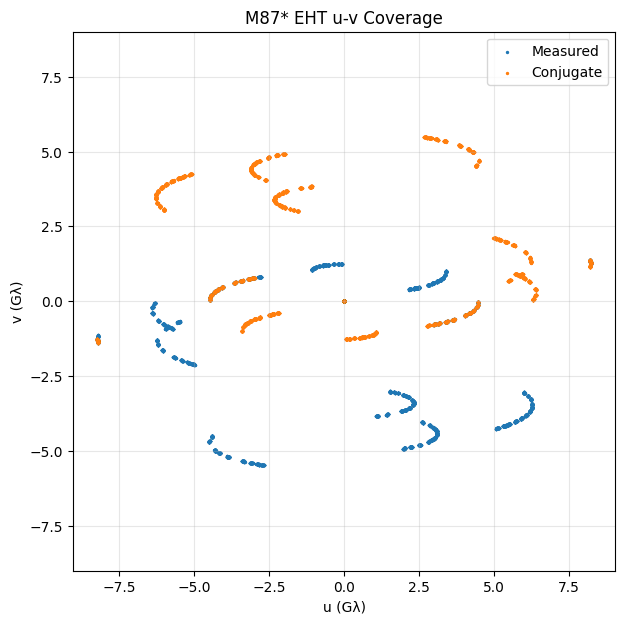

In [59]:
plt.figure(figsize=(7, 7))
plt.scatter(df["u_Glambda"], df["v_Glambda"], s=2, label="Measured")
plt.scatter(-df["u_Glambda"], -df["v_Glambda"], s=2, label="Conjugate")
plt.xlabel("u (Gλ)")
plt.ylabel("v (Gλ)")
plt.title("M87* EHT u-v Coverage")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Visibility Amplitudes Binned across Baseline Lengths



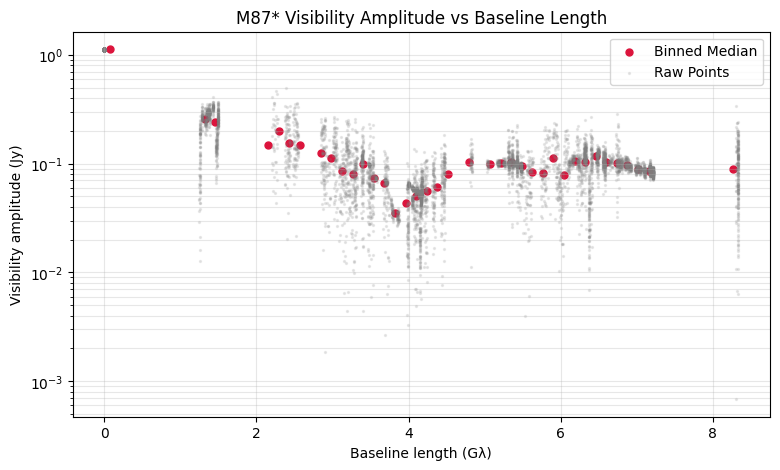

In [60]:
n_bins = 60
bin_edges = np.linspace(df["baseline_Glambda"].min(), df["baseline_Glambda"].max(), n_bins + 1)
df["baseline_bin"] = pd.cut(df["baseline_Glambda"], bins=bin_edges)

grouped = df.groupby("baseline_bin", observed=True)
binned_amplitude = grouped["amplitude"].median()
bin_centers = np.array([interval.mid for interval in binned_amplitude.index])

plt.figure(figsize=(9, 5))
plt.scatter(bin_centers, binned_amplitude, color="crimson", s=25, label="Binned Median")
plt.scatter(df["baseline_Glambda"], df["amplitude"], s=2, alpha=0.15, color="gray", label="Raw Points")
plt.xlabel("Baseline length (Gλ)")
plt.ylabel("Visibility amplitude (Jy)")
plt.yscale("log")
plt.title("M87* Visibility Amplitude vs Baseline Length")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## 4. Image Reconstruction Setup ⚙️

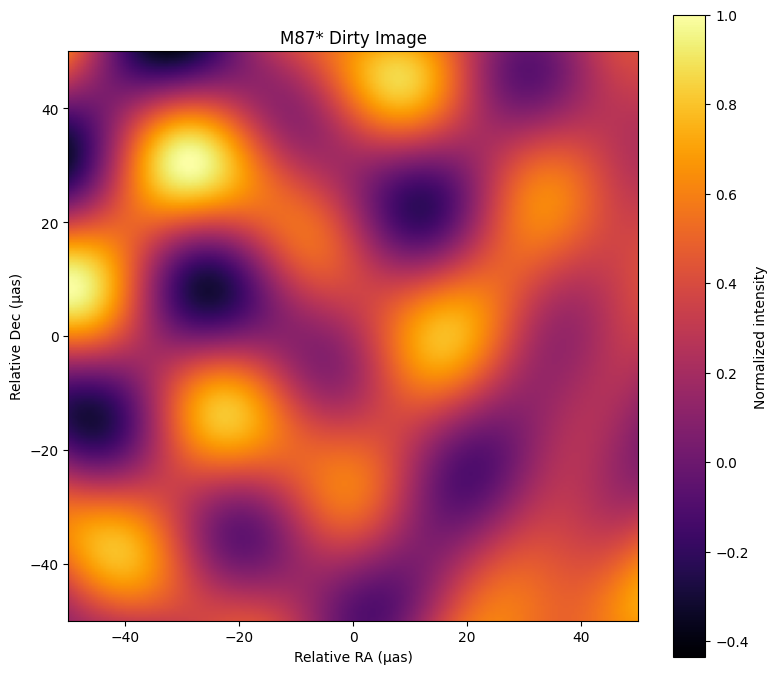

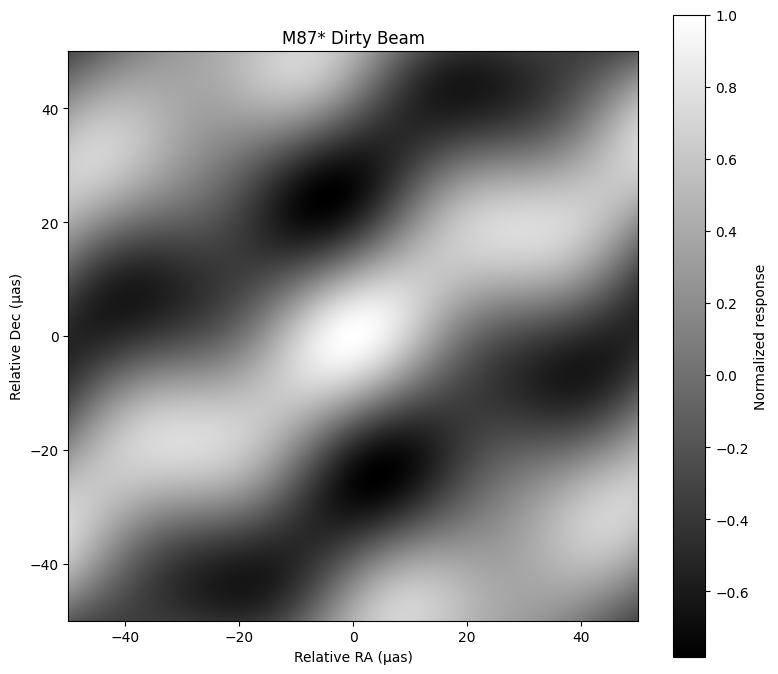

In [4]:
# %% [markdown]
# ## 4. Simple Dirty Image Reconstruction

# %%

# Image size
N = 256
FOV_UAS = 128.0

# Convert microarcseconds to radians
uas_to_rad = np.pi / (180 * 3600 * 1e6)

# Image pixel size
pixel_rad = FOV_UAS * uas_to_rad / N

# Image coordinates
axis = (np.arange(N) - (N - 1) / 2) * pixel_rad
X, Y = np.meshgrid(axis, axis)

# ------------------------------------------------------------
# Prepare visibility data
# ------------------------------------------------------------

visibility = real + 1j * imag

good = (
    np.isfinite(u_sec) &
    np.isfinite(v_sec) &
    np.isfinite(visibility.real) &
    np.isfinite(visibility.imag) &
    np.isfinite(weight) &
    (weight > 0)
)

u0 = u_sec[good]
v0 = v_sec[good]
V0 = visibility[good]
W0 = weight[good]

# Convert seconds -> wavelengths
frequency = header["CRVAL4"]

u0 *= frequency
v0 *= frequency

# Add Hermitian conjugates
u_all = np.r_[u0, -u0]
v_all = np.r_[v0, -v0]
V_all = np.r_[V0, np.conj(V0)]
W_all = np.r_[W0, W0]

# ------------------------------------------------------------
# Direct inverse Fourier transform
# ------------------------------------------------------------

dirty = np.zeros((N, N), dtype=np.complex128)
beam = np.zeros((N, N), dtype=np.complex128)

for ui, vi, Vi, wi in zip(u_all, v_all, V_all, W_all):

    phase = np.exp(
        2j * np.pi * (ui * X + vi * Y)
    )

    dirty += wi * Vi * phase
    beam += wi * phase

# Normalize
dirty = dirty.real / W_all.sum()
beam = beam.real / W_all.sum()

dirty /= np.max(np.abs(dirty))
beam /= np.max(np.abs(beam))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

extent = [
    axis[0] / uas_to_rad,
    axis[-1] / uas_to_rad,
    axis[0] / uas_to_rad,
    axis[-1] / uas_to_rad
]

plt.figure(figsize=(8, 7))

plt.imshow(
    dirty,
    origin="lower",
    extent=extent,
    cmap="inferno"
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Image")

plt.colorbar(label="Normalized intensity")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Dirty beam
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

plt.imshow(
    beam,
    origin="lower",
    extent=extent,
    cmap="gray"
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Beam")

plt.colorbar(label="Normalized response")
plt.tight_layout()
plt.show()

In [ ]:
# %% [markdown]
# ## 5. Simple Regularized M87* Reconstruction

# %%

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

N = 128
FOV_UAS = 128.0
MAXITER = 100

ENTROPY = 0.002
SMOOTH = 0.01

uas_to_rad = np.pi / (180 * 3600 * 1e6)
pixel = FOV_UAS * uas_to_rad / N

axis = (np.arange(N) - (N - 1) / 2) * pixel
X, Y = np.meshgrid(axis, axis)

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

V = real + 1j * imag

good = (
    np.isfinite(u_sec) &
    np.isfinite(v_sec) &
    np.isfinite(V.real) &
    np.isfinite(V.imag) &
    np.isfinite(weight) &
    (weight > 0)
)

u = u_sec[good] * header["CRVAL4"]
v = v_sec[good] * header["CRVAL4"]
V = V[good]
W = weight[good]

# Hermitian completion
u = np.r_[u, -u]
v = np.r_[v, -v]
V = np.r_[V, np.conj(V)]
W = np.r_[W, W]

W = W / np.median(W)

# ------------------------------------------------------------
# Initial image
# ------------------------------------------------------------

flux = np.median(np.abs(V))

sigma = 15 * uas_to_rad

g = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
g /= g.sum()

q0 = np.log(g.ravel() + 1e-12)
z0 = np.r_[q0, np.log(flux)]

# ------------------------------------------------------------
# Fourier model
# ------------------------------------------------------------

def model(z):

    q = z[:-1]
    q = q - q.max()

    p = np.exp(np.clip(q, -30, 30))
    p /= p.sum()

    f = np.exp(z[-1])

    image = f * p.reshape(N, N) / pixel**2

    result = np.empty(len(u), complex)

    for i in range(len(u)):
        phase = np.exp(
            -2j * np.pi * (u[i] * X + v[i] * Y)
        )

        result[i] = np.sum(
            image * phase
        ) * pixel**2

    return image, result

# ------------------------------------------------------------
# Objective
# ------------------------------------------------------------

def objective(z):

    image, predicted = model(z)

    residual = predicted - V

    chi2 = np.sum(
        W * np.abs(residual)**2
    ) / W.sum()

    p = image * pixel**2
    p /= p.sum()

    entropy = np.sum(
        p * np.log(p + 1e-12)
    )

    dx = np.diff(image, axis=1)
    dy = np.diff(image, axis=0)

    smooth = (
        np.mean(dx**2) +
        np.mean(dy**2)
    ) / (np.mean(image)**2 + 1e-20)

    return (
        chi2 +
        ENTROPY * entropy +
        SMOOTH * smooth
    )

# ------------------------------------------------------------
# Optimise
# ------------------------------------------------------------

print("Starting reconstruction...")

result = minimize(
    objective,
    z0,
    method="L-BFGS-B",
    options={"maxiter": MAXITER}
)

print("Finished:", result.success)
print("Iterations:", result.nit)

# ------------------------------------------------------------
# Final image
# ------------------------------------------------------------

image, predicted = model(result.x)

image /= image.max()

extent = [
    axis[0] / uas_to_rad,
    axis[-1] / uas_to_rad,
    axis[0] / uas_to_rad,
    axis[-1] / uas_to_rad
]

plt.figure(figsize=(8, 7))

plt.imshow(
    image,
    origin="lower",
    extent=extent,
    cmap="inferno"
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Regularized Reconstruction")

plt.colorbar(label="Normalized intensity")
plt.tight_layout()
plt.show()

Starting reconstruction...


ValueError: operands could not be broadcast together with shapes (16384,) (128,128) 